# 05 — Real OS / Environment Comparison

**Benchmark:** Benchmark 4 — Real Data OS / Environment Comparison  
**Scope:** Real Amazon Reviews benchmark, Windows local vs Linux/Google Colab environment.  
**Frameworks:** Pandas, Polars eager, Polars lazy, Dask.  
**Important hardware note:** Windows was run on a local machine with about **16 GB RAM**. Colab/Linux was run on a runtime with about **12 GB RAM** and stricter runtime termination behavior.

Notebook này không chạy benchmark workload. Notebook chỉ đọc kết quả đã có trong `results/raw/` và kiểm tra mức độ nhạy của benchmark với môi trường chạy.

Vì hai môi trường không cùng phần cứng và không cùng resource policy, notebook này được diễn giải là **environment comparison**, không phải pure operating-system comparison. Đặc biệt, mốc `50M` trên Colab/Linux bị runtime terminate do memory pressure, nên không có runtime để so sánh tốc độ.

## 1. Research Questions

Notebook này trả lời năm câu hỏi chính:

1. Với các mốc có đủ dữ liệu (`1M`, `10M`), ranking giữa framework có ổn định giữa Windows local và Colab/Linux không?
2. Runtime và peak memory khác nhau như thế nào giữa hai môi trường?
3. Workload nào nhạy nhất với môi trường chạy?
4. Việc Colab/Linux không hoàn thành `50M` nói gì về stability và memory pressure?
5. Kết quả này nên được đưa vào report như thế nào để không bị hiểu nhầm là Linux chậm hơn Windows?

## 2. Methodology Boundary

Benchmark này là **end-to-end dataframe analytics benchmark**. Runtime bao gồm đọc parquet, execute workload, memory allocation, materialization, OS cache, pagefile/swap behavior, memory pressure, và runtime policy.

Vì vậy, nếu một workload `50M` chạy được trên Windows local nhờ pagefile nhưng bị Colab/Linux terminate do vượt giới hạn RAM/runtime, đó là một kết quả thực tế quan trọng về **resource sensitivity**. Tuy nhiên, nó không được dùng để kết luận rằng Linux chậm hơn Windows.

In [1]:
import pandas as pd

comparison_boundary = pd.DataFrame([
    {
        "comparison": "Windows local vs Colab/Linux at 1M and 10M",
        "validity": "valid with caveat",
        "interpretation": "Environment comparison on completed runs; hardware and resource policies differ.",
    },
    {
        "comparison": "Windows 50M runtime vs missing Colab/Linux 50M runtime",
        "validity": "invalid as speed comparison",
        "interpretation": "Treat Colab/Linux 50M as failure/stability observation caused by memory pressure.",
    },
    {
        "comparison": "Windows vs Linux as pure OS comparison",
        "validity": "invalid in this setup",
        "interpretation": "Pure OS comparison requires the same physical hardware and comparable resource limits.",
    },
    {
        "comparison": "Framework robustness under constrained Colab memory",
        "validity": "valid",
        "interpretation": "Missing or terminated large runs indicate sensitivity to memory limits and materialization behavior.",
    },
])

display(comparison_boundary)

,comparison,validity,interpretation
0,Windows local vs Colab/Linux at 1M and 10M,valid with caveat,Environment comparison on completed runs; hard...
1,Windows 50M runtime vs missing Colab/Linux 50M...,invalid as speed comparison,Treat Colab/Linux 50M as failure/stability obs...
2,Windows vs Linux as pure OS comparison,invalid in this setup,Pure OS comparison requires the same physical ...
3,Framework robustness under constrained Colab m...,valid,Missing or terminated large runs indicate sens...


## 3. Setup and Data Loading

Code dùng key và tên biến tiếng Anh để khớp với CSV benchmark. Nội dung markdown dùng tiếng Việt để giải thích kết quả.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() in {"benchmark", "benchmarks", "analysis", "report", "data_prep"}:
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()
elif PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

RAW_DIR = PROJECT_ROOT / "results" / "raw"

WINDOWS_FILES = [
    "pandas_real_results.csv",
    "polars_real_results.csv",
    "polars_eager_real_results.csv",
    "dask_real_results.csv",
]

COLAB_FILES = [
    "pandas_colab_results.csv",
    "polars_colab_results.csv",
    "polars_eager_colab_results.csv",
    "dask_colab_results.csv",
]

ROW_ORDER = ["1M", "10M", "50M"]
WORKLOAD_ORDER = ["filter", "groupby", "join", "pipeline"]
FRAMEWORK_ORDER = ["pandas", "polars_eager", "polars_lazy", "dask"]
ENV_ORDER = ["windows_local_16gb", "colab_linux_12gb"]

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"

In [3]:
def load_environment(files, environment):
    frames = []
    missing = []
    for name in files:
        path = RAW_DIR / name
        if not path.exists():
            missing.append(name)
            continue
        frame = pd.read_csv(path)
        frame["environment"] = environment
        frame["source_file"] = name
        frames.append(frame)
    return frames, missing


windows_frames, missing_windows = load_environment(WINDOWS_FILES, "windows_local_16gb")
colab_frames, missing_colab = load_environment(COLAB_FILES, "colab_linux_12gb")

missing_files = missing_windows + missing_colab
if missing_files:
    print("Missing files:", missing_files)

if not windows_frames or not colab_frames:
    raise FileNotFoundError("Both Windows/local and Colab/Linux result files are required for this notebook.")

df_raw = pd.concat(windows_frames + colab_frames, ignore_index=True)
df_raw["dataset_size"] = pd.Categorical(df_raw["dataset_size"], ROW_ORDER, ordered=True)
df_raw["workload"] = pd.Categorical(df_raw["workload"], WORKLOAD_ORDER, ordered=True)
df_raw["framework"] = pd.Categorical(df_raw["framework"], FRAMEWORK_ORDER, ordered=True)
df_raw["environment"] = pd.Categorical(df_raw["environment"], ENV_ORDER, ordered=True)

print(f"Loaded {len(df_raw):,} benchmark rows from {df_raw['source_file'].nunique()} files.")
display(
    df_raw
    .groupby(["environment", "source_file"], observed=True)
    .size()
    .rename("rows")
    .reset_index()
)

Loaded 240 benchmark rows from 8 files.


,environment,source_file,rows
0,windows_local_16gb,dask_real_results.csv,36
1,windows_local_16gb,pandas_real_results.csv,36
2,windows_local_16gb,polars_eager_real_results.csv,36
3,windows_local_16gb,polars_real_results.csv,36
4,colab_linux_12gb,dask_colab_results.csv,24
5,colab_linux_12gb,pandas_colab_results.csv,24
6,colab_linux_12gb,polars_colab_results.csv,24
7,colab_linux_12gb,polars_eager_colab_results.csv,24


## 4. Data Completeness and Failure Scope

`status == "ok"` được dùng cho runtime/memory comparison. Các tổ hợp không có dữ liệu, đặc biệt `50M` trên Colab/Linux, được phân tích riêng như failure/stability observation.

In [4]:
df_ok = df_raw[df_raw["status"] == "ok"].copy()
df_fail = df_raw[df_raw["status"] != "ok"].copy()

run_count = (
    df_raw
    .groupby(["environment", "framework", "workload", "dataset_size", "status"], observed=True)
    .size()
    .rename("n_runs")
    .reset_index()
)

display(run_count)

,environment,framework,workload,dataset_size,status,n_runs
0,windows_local_16gb,pandas,filter,1M,ok,3
1,windows_local_16gb,pandas,filter,10M,ok,3
2,windows_local_16gb,pandas,filter,50M,ok,3
3,windows_local_16gb,pandas,groupby,1M,ok,3
4,windows_local_16gb,pandas,groupby,10M,ok,3
...,...,...,...,...,...,...
75,colab_linux_12gb,dask,groupby,10M,ok,3
76,colab_linux_12gb,dask,join,1M,ok,3
77,colab_linux_12gb,dask,join,10M,ok,3
78,colab_linux_12gb,dask,pipeline,1M,ok,3


In [5]:
observed_success = (
    df_ok
    .groupby(["environment", "framework", "workload", "dataset_size"], observed=True)
    .size()
    .rename("successful_runs")
    .reset_index()
)

expected = pd.MultiIndex.from_product(
    [ENV_ORDER, FRAMEWORK_ORDER, WORKLOAD_ORDER, ROW_ORDER],
    names=["environment", "framework", "workload", "dataset_size"],
).to_frame(index=False)

completeness = expected.merge(
    observed_success,
    on=["environment", "framework", "workload", "dataset_size"],
    how="left",
)
completeness["successful_runs"] = completeness["successful_runs"].fillna(0).astype(int)
completeness["completion_status"] = np.where(completeness["successful_runs"] > 0, "ok", "missing_or_not_completed")

missing_observations = completeness[completeness["completion_status"] != "ok"].copy()
missing_observations["interpretation"] = np.where(
    (missing_observations["environment"] == "colab_linux_12gb") & (missing_observations["dataset_size"] == "50M"),
    "Colab/Linux run was terminated or not completed under memory pressure; no runtime is reported.",
    "No successful run is present in the raw result files.",
)

completion_matrix = completeness.pivot_table(
    index=["environment", "framework", "workload"],
    columns="dataset_size",
    values="successful_runs",
    observed=True,
    fill_value=0,
)

display(completion_matrix)
display(missing_observations)

dataset_size                              10M   1M  50M
environment        framework    workload               
colab_linux_12gb   dask         filter    3.0  3.0  0.0
                                groupby   3.0  3.0  0.0
                                join      3.0  3.0  0.0
                                pipeline  3.0  3.0  0.0
                   pandas       filter    3.0  3.0  0.0
                                groupby   3.0  3.0  0.0
                                join      3.0  3.0  0.0
                                pipeline  3.0  3.0  0.0
                   polars_eager filter    3.0  3.0  0.0
                                groupby   3.0  3.0  0.0
                                join      3.0  3.0  0.0
                                pipeline  3.0  3.0  0.0
                   polars_lazy  filter    3.0  3.0  0.0
                                groupby   3.0  3.0  0.0
                                join      3.0  3.0  0.0
                                pipeline  3.0  3.0  0.0
windows_local_16gb dask         filter    3.0  3.0  3.0
                                groupby   3.0  3.0  3.0
                                join      3.0  3.0  3.0
                                pipeline  3.0  3.0  3.0
                   pandas       filter    3.0  3.0  3.0
                                groupby   3.0  3.0  3.0
                                join      3.0  3.0  3.0
                                pipeline  3.0  3.0  3.0
                   polars_eager filter    3.0  3.0  3.0
                                groupby   3.0  3.0  3.0
                                join      3.0  3.0  3.0
                                pipeline  3.0  3.0  3.0
                   polars_lazy  filter    3.0  3.0  3.0
                                groupby   3.0  3.0  3.0
                                join      3.0  3.0  3.0
                                pipeline  3.0  3.0  3.0

,environment,framework,workload,dataset_size,successful_runs,completion_status,interpretation
50,colab_linux_12gb,pandas,filter,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...
53,colab_linux_12gb,pandas,groupby,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...
56,colab_linux_12gb,pandas,join,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...
59,colab_linux_12gb,pandas,pipeline,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...
62,colab_linux_12gb,polars_eager,filter,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...
65,colab_linux_12gb,polars_eager,groupby,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...
68,colab_linux_12gb,polars_eager,join,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...
71,colab_linux_12gb,polars_eager,pipeline,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...
74,colab_linux_12gb,polars_lazy,filter,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...
77,colab_linux_12gb,polars_lazy,groupby,50M,0,missing_or_not_completed,Colab/Linux run was terminated or not complete...


### Completeness Interpretation

Windows local có đủ kết quả `1M`, `10M`, `50M`. Colab/Linux có kết quả `1M` và `10M`, nhưng không có `50M` vì runtime bị kill do memory pressure/OOM.

Vì vậy, mọi ratio Windows-vs-Colab ở các phần sau chỉ được tính trên các cặp có đủ dữ liệu ở cả hai môi trường. `50M` không được đưa vào speed ratio; nó được báo cáo là stability/failure observation.

## 5. Aggregated Results

Bảng `summary` là nguồn chính cho các phân tích tiếp theo. Mỗi tổ hợp được tổng hợp bằng mean, standard deviation, và số successful runs.

In [6]:
summary = (
    df_ok
    .groupby(["environment", "framework", "workload", "dataset_size"], observed=True)
    .agg(
        mean_time_s=("time_s", "mean"),
        std_time_s=("time_s", "std"),
        mean_peak_memory_mb=("peak_memory_mb", "mean"),
        std_peak_memory_mb=("peak_memory_mb", "std"),
        mean_throughput_rows_per_s=("throughput_rows_per_s", "mean"),
        std_throughput_rows_per_s=("throughput_rows_per_s", "std"),
        mean_n_rows=("n_rows", "mean"),
        successful_runs=("run_index", "count"),
    )
    .reset_index()
)

summary["mean_time_min"] = summary["mean_time_s"] / 60
summary["mean_peak_memory_gb"] = summary["mean_peak_memory_mb"] / 1024
summary["throughput_mrows_per_s"] = summary["mean_throughput_rows_per_s"] / 1_000_000
summary["runtime_cv"] = summary["std_time_s"] / summary["mean_time_s"]

display(
    summary
    .sort_values(["environment", "dataset_size", "workload", "framework"])
    .round(3)
)

,environment,framework,workload,dataset_size,mean_time_s,std_time_s,mean_peak_memory_mb,std_peak_memory_mb,mean_throughput_rows_per_s,std_throughput_rows_per_s,mean_n_rows,successful_runs,mean_time_min,mean_peak_memory_gb,throughput_mrows_per_s,runtime_cv
0,windows_local_16gb,pandas,filter,1M,2.052,0.045,1356.333,13.807,487402.667,10562.018,1000000.0,3,0.034,1.325,0.487,0.022
12,windows_local_16gb,polars_eager,filter,1M,0.317,0.008,763.840,63.886,3155034.000,79804.987,1000000.0,3,0.005,0.746,3.155,0.026
24,windows_local_16gb,polars_lazy,filter,1M,0.371,0.003,688.360,16.613,2696172.000,20903.454,1000000.0,3,0.006,0.672,2.696,0.008
36,windows_local_16gb,dask,filter,1M,0.692,0.012,1006.843,36.851,1446202.333,24508.972,1000000.0,3,0.012,0.983,1.446,0.017
3,windows_local_16gb,pandas,groupby,1M,2.634,0.067,1381.780,8.836,379822.333,9739.419,1000000.0,3,0.044,1.349,0.380,0.025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,colab_linux_12gb,dask,join,10M,15.632,0.570,4619.707,57.158,640280.667,22960.169,10000000.0,3,0.261,4.511,0.640,0.036
55,colab_linux_12gb,pandas,pipeline,10M,37.381,0.454,6813.487,36.341,267540.333,3262.125,10000000.0,3,0.623,6.654,0.268,0.012
63,colab_linux_12gb,polars_eager,pipeline,10M,7.195,0.271,5237.383,24.129,1391253.333,51925.688,10000000.0,3,0.120,5.115,1.391,0.038
71,colab_linux_12gb,polars_lazy,pipeline,10M,4.979,0.380,2110.753,419.986,2016517.333,155406.182,10000000.0,3,0.083,2.061,2.017,0.076


## 6. Runtime Comparison on Completed Common Sizes

Phần này chỉ dùng `1M` và `10M`, vì đây là các row count có đủ dữ liệu ở cả Windows local và Colab/Linux.

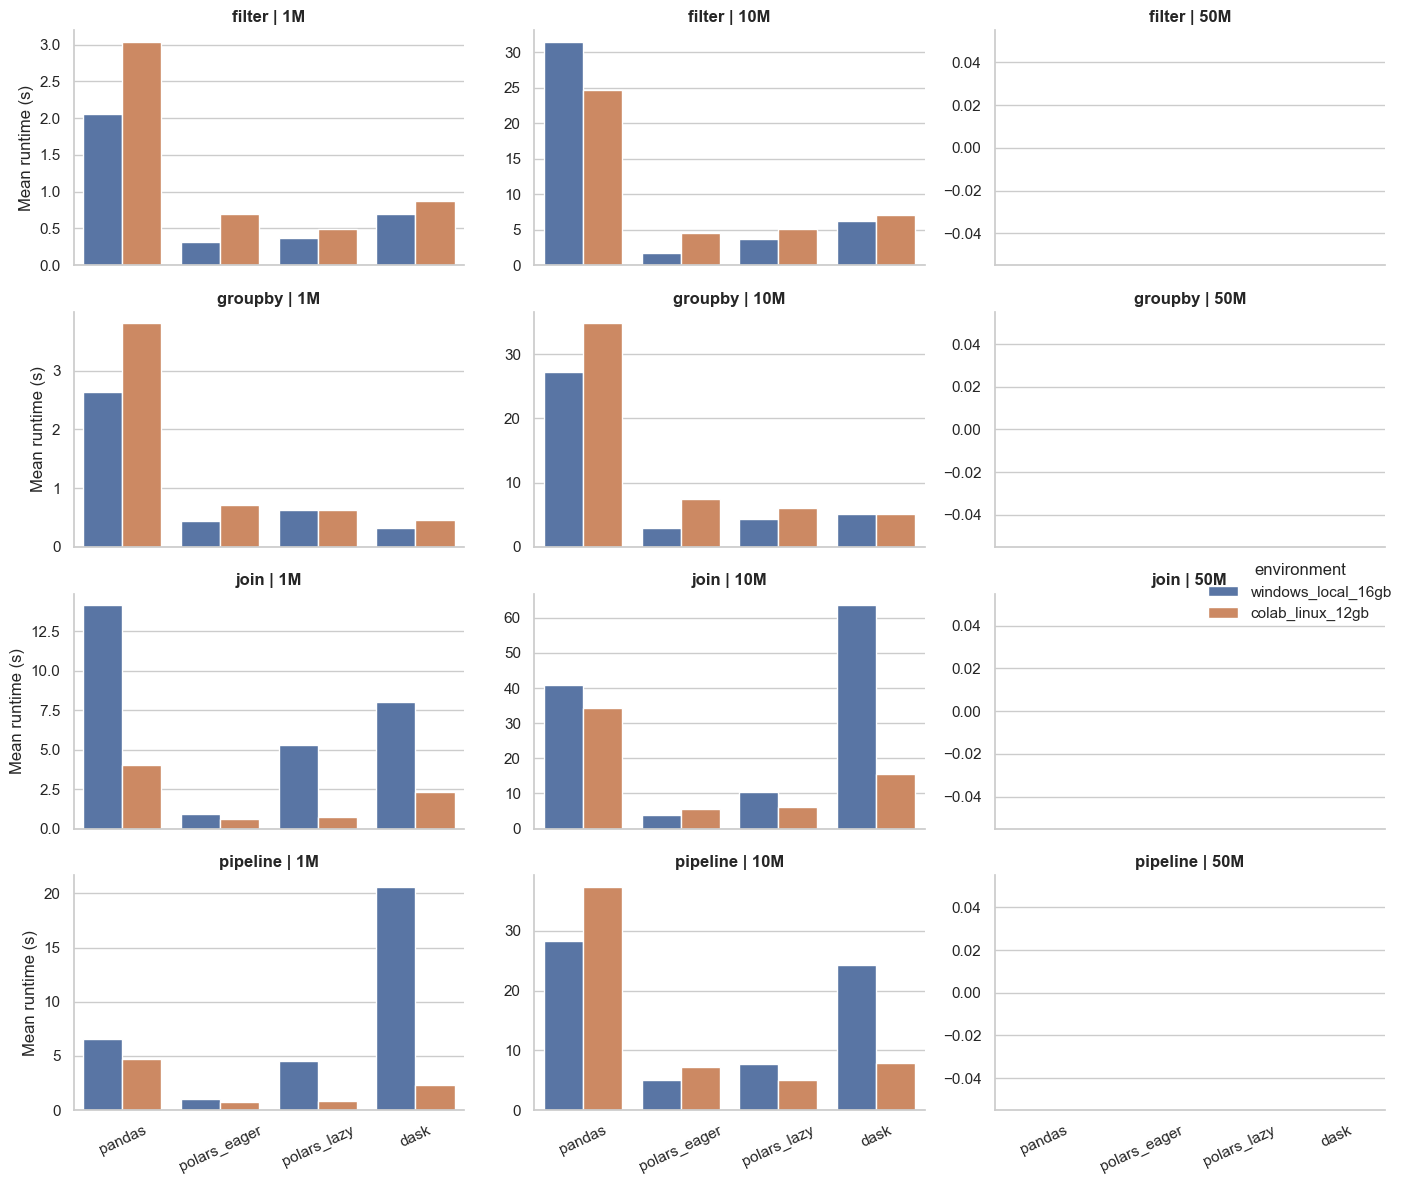

In [7]:
common_sizes = (
    summary
    .groupby(["framework", "workload", "dataset_size"], observed=True)["environment"]
    .nunique()
    .reset_index(name="n_environments")
)
common_sizes = common_sizes[common_sizes["n_environments"] == 2][["framework", "workload", "dataset_size"]]

common_summary = summary.merge(common_sizes, on=["framework", "workload", "dataset_size"], how="inner")

g = sns.catplot(
    data=common_summary,
    x="framework",
    y="mean_time_s",
    hue="environment",
    col="dataset_size",
    row="workload",
    kind="bar",
    order=FRAMEWORK_ORDER,
    hue_order=ENV_ORDER,
    sharey=False,
    height=3.0,
    aspect=1.35,
)
g.set_axis_labels("", "Mean runtime (s)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

In [8]:
ratio_wide = (
    common_summary
    .pivot_table(
        index=["framework", "workload", "dataset_size"],
        columns="environment",
        values=["mean_time_s", "mean_peak_memory_mb"],
        observed=True,
    )
)

ratio = pd.DataFrame(index=ratio_wide.index)
ratio["windows_time_s"] = ratio_wide[("mean_time_s", "windows_local_16gb")]
ratio["colab_time_s"] = ratio_wide[("mean_time_s", "colab_linux_12gb")]
ratio["windows_memory_mb"] = ratio_wide[("mean_peak_memory_mb", "windows_local_16gb")]
ratio["colab_memory_mb"] = ratio_wide[("mean_peak_memory_mb", "colab_linux_12gb")]
ratio["windows_over_colab_time"] = ratio["windows_time_s"] / ratio["colab_time_s"]
ratio["windows_over_colab_memory"] = ratio["windows_memory_mb"] / ratio["colab_memory_mb"]
ratio = ratio.reset_index()

display(
    ratio
    .sort_values(["dataset_size", "workload", "framework"])
    .round(3)
)

,framework,workload,dataset_size,windows_time_s,colab_time_s,windows_memory_mb,colab_memory_mb,windows_over_colab_time,windows_over_colab_memory
0,pandas,filter,1M,2.052,3.040,1356.333,1201.160,0.675,1.129
8,polars_eager,filter,1M,0.317,0.701,763.840,615.573,0.452,1.241
16,polars_lazy,filter,1M,0.371,0.492,688.360,647.080,0.753,1.064
24,dask,filter,1M,0.692,0.880,1006.843,1389.413,0.786,0.725
2,pandas,groupby,1M,2.634,3.809,1381.780,1276.903,0.691,1.082
10,polars_eager,groupby,1M,0.435,0.706,829.133,695.237,0.615,1.193
18,polars_lazy,groupby,1M,0.624,0.622,1418.767,581.417,1.002,2.440
26,dask,groupby,1M,0.318,0.458,720.903,787.543,0.694,0.915
4,pandas,join,1M,14.170,4.031,2845.410,1312.983,3.515,2.167
12,polars_eager,join,1M,0.907,0.587,2124.097,639.113,1.546,3.324


### Ratio Interpretation

`windows_over_colab_time > 1` nghĩa là Windows local chậm hơn Colab/Linux trong cặp đó.  
`windows_over_colab_time < 1` nghĩa là Windows local nhanh hơn Colab/Linux trong cặp đó.

Tỷ lệ này phản ánh cả framework behavior lẫn khác biệt phần cứng, RAM, filesystem, CPU allocation, OS cache, pagefile/swap, và Colab runtime policy. Vì vậy, ratio nên được đọc như **environment sensitivity**, không phải pure OS speed.

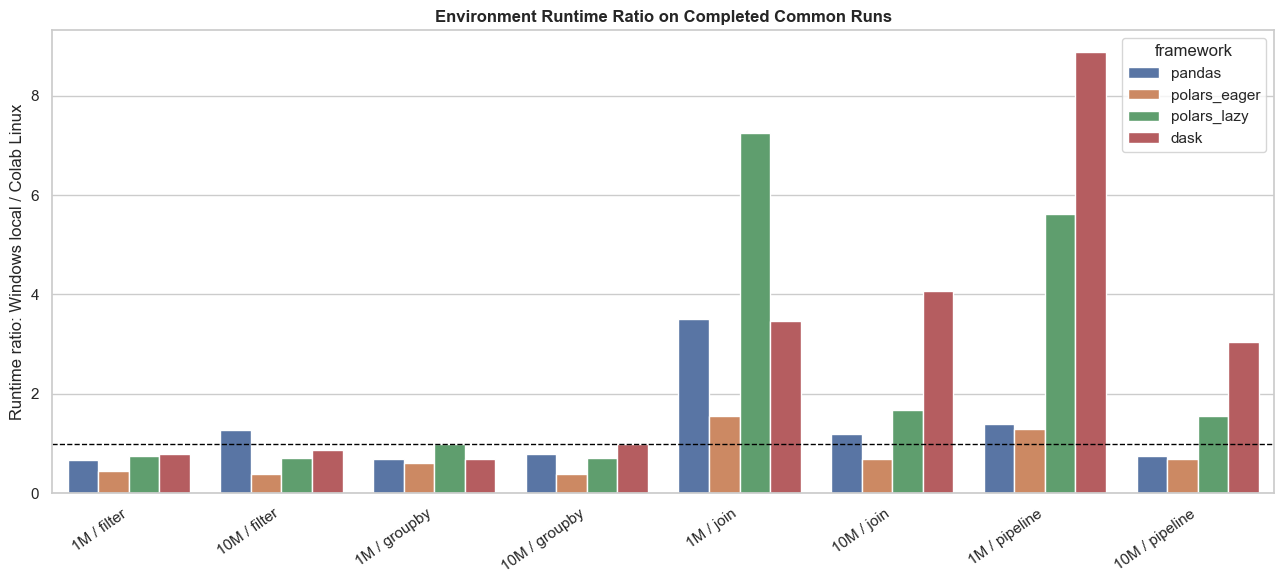

In [9]:
ratio_plot = ratio.copy()
ratio_plot["case"] = ratio_plot["dataset_size"].astype(str) + " / " + ratio_plot["workload"].astype(str)

plt.figure(figsize=(13, 6))
sns.barplot(
    data=ratio_plot,
    x="case",
    y="windows_over_colab_time",
    hue="framework",
    hue_order=FRAMEWORK_ORDER,
)
plt.axhline(1.0, color="black", linewidth=1, linestyle="--")
plt.ylabel("Runtime ratio: Windows local / Colab Linux")
plt.xlabel("")
plt.title("Environment Runtime Ratio on Completed Common Runs")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 7. Memory Comparison

Peak memory được đọc từ benchmark logs. Trên Colab/Linux, peak memory gần giới hạn runtime có thể dẫn tới termination thay vì pagefile-based slowdown như trên Windows.

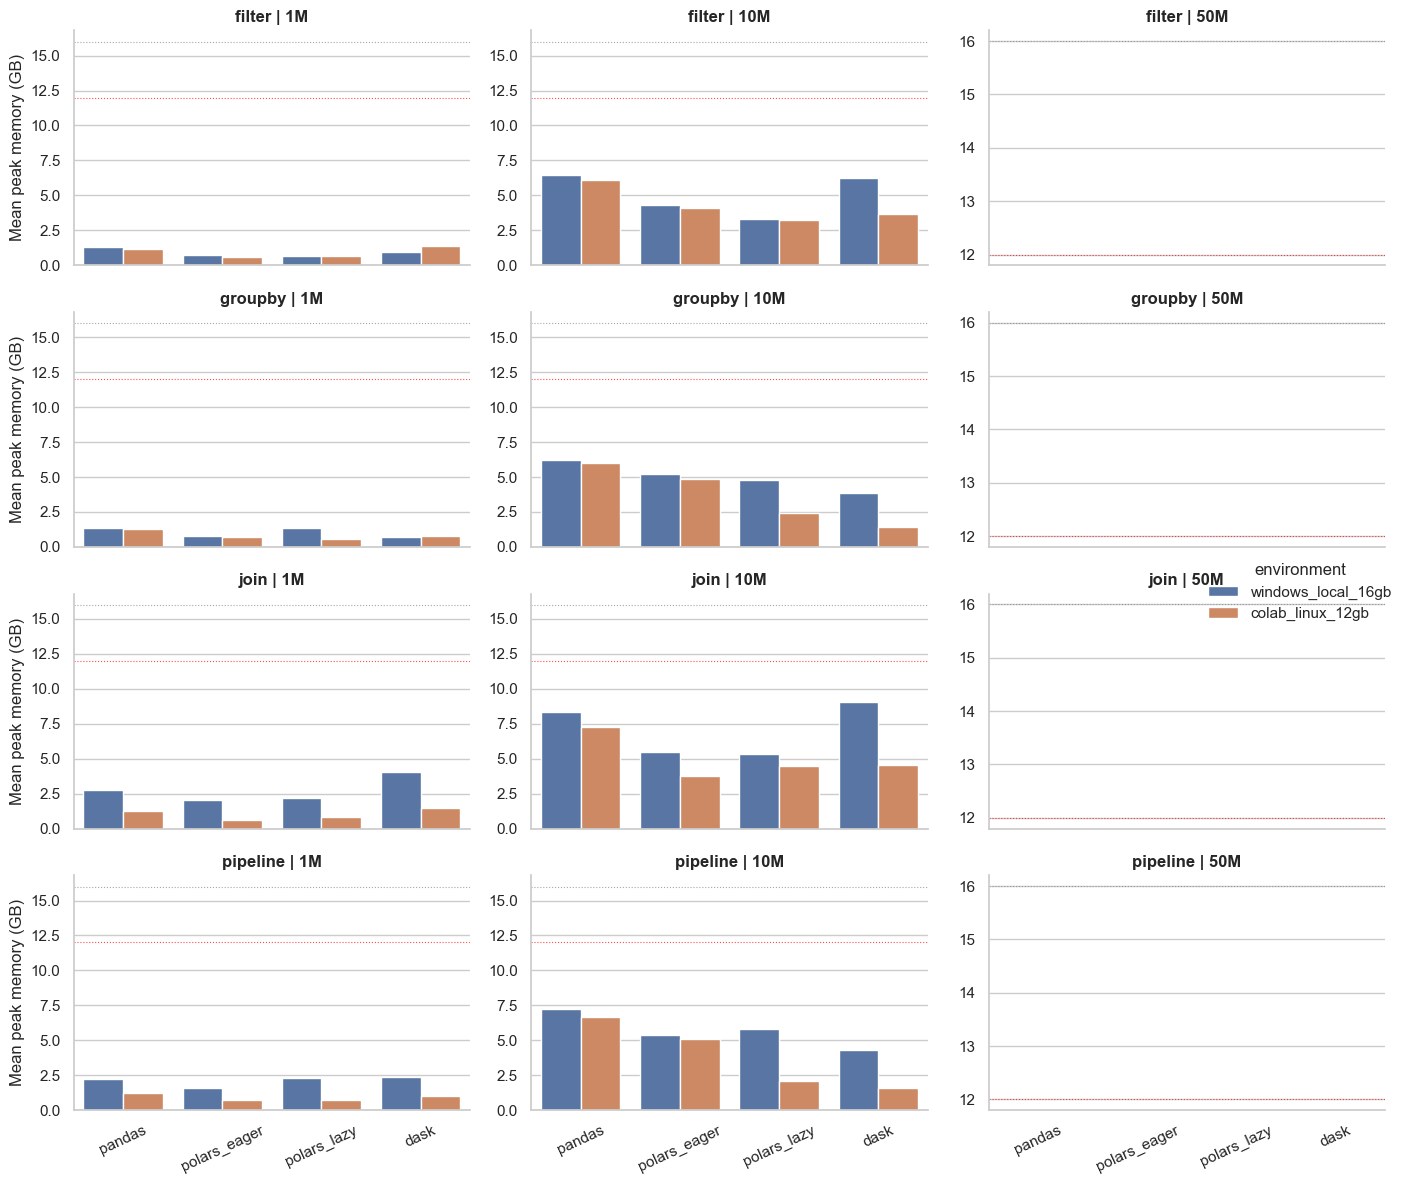

In [10]:
g = sns.catplot(
    data=common_summary,
    x="framework",
    y="mean_peak_memory_gb",
    hue="environment",
    col="dataset_size",
    row="workload",
    kind="bar",
    order=FRAMEWORK_ORDER,
    hue_order=ENV_ORDER,
    sharey=False,
    height=3.0,
    aspect=1.35,
)
g.set_axis_labels("", "Mean peak memory (GB)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=25)
    ax.axhline(12, color="red", linewidth=0.8, linestyle=":", alpha=0.7)
    ax.axhline(16, color="gray", linewidth=0.8, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

## 8. Framework Ranking Stability

Ranking được tính riêng theo environment, workload, và dataset size. Chỉ các successful runs mới được dùng.

In [11]:
ranking = summary.copy()
ranking["runtime_rank"] = (
    ranking
    .groupby(["environment", "workload", "dataset_size"], observed=True)["mean_time_s"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

ranking_table = ranking.pivot_table(
    index=["workload", "dataset_size", "framework"],
    columns="environment",
    values="runtime_rank",
    observed=True,
).reset_index()

ranking_table["rank_delta_abs"] = (
    ranking_table["windows_local_16gb"] - ranking_table["colab_linux_12gb"]
).abs()

display(
    ranking_table
    .sort_values(["dataset_size", "workload", "rank_delta_abs", "framework"], ascending=[True, True, False, True])
)

environment,workload,dataset_size,framework,windows_local_16gb,colab_linux_12gb,rank_delta_abs
1,filter,1M,polars_eager,1.0,2.0,1.0
2,filter,1M,polars_lazy,2.0,1.0,1.0
0,filter,1M,pandas,4.0,4.0,0.0
3,filter,1M,dask,3.0,3.0,0.0
13,groupby,1M,polars_eager,2.0,3.0,1.0
14,groupby,1M,polars_lazy,3.0,2.0,1.0
12,groupby,1M,pandas,4.0,4.0,0.0
15,groupby,1M,dask,1.0,1.0,0.0
24,join,1M,pandas,4.0,4.0,0.0
25,join,1M,polars_eager,1.0,1.0,0.0


In [12]:
best_by_environment = (
    ranking[ranking["runtime_rank"] == 1]
    [["environment", "dataset_size", "workload", "framework", "mean_time_s", "mean_peak_memory_gb"]]
    .sort_values(["dataset_size", "workload", "environment"])
)

display(best_by_environment.round(3))

,environment,dataset_size,workload,framework,mean_time_s,mean_peak_memory_gb
12,windows_local_16gb,1M,filter,polars_eager,0.317,0.746
64,colab_linux_12gb,1M,filter,polars_lazy,0.492,0.632
39,windows_local_16gb,1M,groupby,dask,0.318,0.704
74,colab_linux_12gb,1M,groupby,dask,0.458,0.769
18,windows_local_16gb,1M,join,polars_eager,0.907,2.074
60,colab_linux_12gb,1M,join,polars_eager,0.587,0.624
21,windows_local_16gb,1M,pipeline,polars_eager,1.031,1.579
62,colab_linux_12gb,1M,pipeline,polars_eager,0.793,0.722
13,windows_local_16gb,10M,filter,polars_eager,1.793,4.320
57,colab_linux_12gb,10M,filter,polars_eager,4.493,4.080


## 9. The 50M Colab/Linux Outcome

`50M` là điểm quan trọng nhất về stability. Windows local có successful runs ở `50M`, trong khi Colab/Linux không có successful run trong raw CSV do runtime bị kill vì memory pressure.

Đây là kết quả thực tế: người dùng thật cũng bị giới hạn bởi RAM, pagefile/swap, và runtime policy của môi trường chạy. Nhưng đây **không phải** là runtime comparison.

In [13]:
windows_50m = (
    summary[
        (summary["environment"] == "windows_local_16gb")
        & (summary["dataset_size"].astype(str) == "50M")
    ]
    .sort_values(["workload", "framework"])
    .copy()
)

display(
    windows_50m[
        [
            "framework",
            "workload",
            "mean_time_s",
            "std_time_s",
            "mean_time_min",
            "mean_peak_memory_gb",
            "successful_runs",
        ]
    ].round(3)
)

,framework,workload,mean_time_s,std_time_s,mean_time_min,mean_peak_memory_gb,successful_runs
2,pandas,filter,724.352,0.930,12.073,11.296,3
14,polars_eager,filter,53.202,1.835,0.887,7.747,3
26,polars_lazy,filter,30.594,1.291,0.510,12.151,3
38,dask,filter,33.803,3.318,0.563,10.341,3
5,pandas,groupby,440.839,30.522,7.347,11.132,3
17,polars_eager,groupby,79.645,1.826,1.327,8.792,3
29,polars_lazy,groupby,18.763,0.554,0.313,11.910,3
41,dask,groupby,11.238,0.405,0.187,4.585,3
8,pandas,join,1552.661,5.668,25.878,11.182,3
20,polars_eager,join,53.395,4.461,0.890,6.934,3


In [14]:
colab_50m_failure = pd.DataFrame([
    {
        "environment": "colab_linux_12gb",
        "dataset_size": "50M",
        "status": "not_completed",
        "reported_runtime": "not reported",
        "interpretation": "Runtime was terminated under memory pressure/OOM; treat as stability observation, not speed comparison.",
    }
])

display(colab_50m_failure)

,environment,dataset_size,status,reported_runtime,interpretation
0,colab_linux_12gb,50M,not_completed,not reported,Runtime was terminated under memory pressure/O...


Recommended report wording:

> For the 50M-row Linux/Colab run, the workload was terminated by the runtime due to memory pressure. Therefore, no runtime is reported. This result is treated as a failure/stability observation, not as a speed comparison. Since Windows local and Linux Colab do not run on identical hardware and resource policies, this experiment is interpreted as an environment comparison rather than a pure operating-system comparison.

## 10. Workload Sensitivity Summary

Một workload được xem là environment-sensitive nếu runtime ratio lệch xa `1.0`, memory ratio lệch mạnh, hoặc chỉ hoàn thành ở một môi trường.

In [15]:
sensitivity = (
    ratio
    .groupby(["workload", "dataset_size"], observed=True)
    .agg(
        median_time_ratio=("windows_over_colab_time", "median"),
        max_time_ratio=("windows_over_colab_time", "max"),
        min_time_ratio=("windows_over_colab_time", "min"),
        median_memory_ratio=("windows_over_colab_memory", "median"),
    )
    .reset_index()
)
sensitivity["time_ratio_spread"] = sensitivity["max_time_ratio"] / sensitivity["min_time_ratio"]

display(sensitivity.round(3))

,workload,dataset_size,median_time_ratio,max_time_ratio,min_time_ratio,median_memory_ratio,time_ratio_spread
0,filter,1M,0.714,0.786,0.452,1.096,1.737
1,filter,10M,0.798,1.273,0.399,1.056,3.191
2,groupby,1M,0.693,1.002,0.615,1.137,1.629
3,groupby,10M,0.746,0.999,0.392,1.521,2.546
4,join,1M,3.487,7.250,1.546,2.677,4.689
5,join,10M,1.433,4.072,0.692,1.329,5.884
6,pipeline,1M,3.513,8.868,1.300,2.278,6.820
7,pipeline,10M,1.161,3.053,0.692,1.892,4.413


In [16]:
environment_observations = pd.DataFrame([
    {
        "observation": "1M and 10M completed on both environments",
        "meaning": "These sizes can be used for environment-level runtime and memory comparison.",
    },
    {
        "observation": "50M completed on Windows local but not on Colab/Linux",
        "meaning": "The large real workload is sensitive to memory limits and runtime termination policy.",
    },
    {
        "observation": "Windows local has about 16 GB RAM and pagefile behavior",
        "meaning": "A workload may slow down but still finish under memory pressure.",
    },
    {
        "observation": "Colab/Linux has about 12 GB RAM and stricter runtime termination",
        "meaning": "A workload may be killed instead of completing slowly.",
    },
])

display(environment_observations)

,observation,meaning
0,1M and 10M completed on both environments,These sizes can be used for environment-level ...
1,50M completed on Windows local but not on Cola...,The large real workload is sensitive to memory...
2,Windows local has about 16 GB RAM and pagefile...,A workload may slow down but still finish unde...
3,Colab/Linux has about 12 GB RAM and stricter r...,A workload may be killed instead of completing...


## 11. Conclusions

1. Notebook này nên được gọi là **Windows local vs Linux Colab environment comparison**, không phải pure Windows-vs-Linux OS comparison.
2. Với `1M` và `10M`, runtime/memory comparison là hợp lệ nếu luôn kèm caveat rằng phần cứng và resource policy khác nhau.
3. Với `50M`, Colab/Linux không có runtime vì workload bị terminate dưới memory pressure. Đây là failure/stability observation.
4. Kết quả `50M` không chứng minh Linux chậm hơn Windows. Nó chứng minh rằng trong môi trường Colab/Linux bị giới hạn tài nguyên, workload `50M` không ổn định hoặc không hoàn thành.
5. Nếu muốn pure OS comparison, cần chạy Windows và Linux trên cùng một máy vật lý, cùng dataset, cùng scripts, cùng framework versions, và resource policy càng giống nhau càng tốt.

Nếu tiếp tục dùng Colab, report nên giữ tên là **environment comparison**. Nếu muốn benchmark công bằng hơn cho `50M`, có thể thêm các control workloads như `filter_count`, `join_count`, hoặc `sink_to_disk` để giảm áp lực materialize output quá lớn.